In [1]:
import numpy as np
from matplotlib import pylab as plt
import torch

In [2]:

def randPair(s, e):
    # 返回一个 [s, e) 范围内的随机坐标 (row, col), 用于随机初始化棋子位置
    return np.random.randint(s, e), np.random.randint(s, e)


class BoardPiece:
    """棋盘上"点状"元素: 玩家 / 目标 / 陷阱 / 墙, 每个只占一个格子."""

    def __init__(self, name, code, pos):
        self.name = name   # 语义名称, 例如 'Player', 'Goal'
        self.code = code   # 渲染成 ASCII 时显示的字符, 例如 'P', '+', '-', 'W'
        self.pos = pos     # 当前所在格子, 2-tuple (row, col)


class BoardMask:
    """棋盘上"区域"元素: 用 0/1 掩码描述一组格子, 典型用途是边界墙.

    与 BoardPiece 的区别在于 BoardMask 一次占用多个格子, 且位置由 mask 数组决定,
    不需要单独维护 pos.
    """

    def __init__(self, name, mask, code):
        self.name = name   # 语义名称, 例如 'boundary'
        self.mask = mask   # 2D numpy 数组, 1 表示该格属于此 mask, 0 表示不属于
        self.code = code   # 渲染时显示的字符

    def get_positions(self):
        # np.nonzero 返回 (rows, cols) 两个数组, 分别是所有值为 1 的格子的行/列下标.
        # 这种"两数组"格式可以直接作为 numpy 的 fancy indexing 使用:
        #   arr[rows, cols] = value  # 一次性写入所有被 mask 覆盖的格子
        # 也可以配合 zip_positions2d 转成 [(r,c), ...] 便于成员判断.
        return np.nonzero(self.mask)


def zip_positions2d(positions):
    # 把 np.nonzero 输出的 (rows, cols) 两数组转成 [(r0,c0), (r1,c1), ...] 的坐标列表.
    # 便于用 `pos in zip_positions2d(...)` 判断某个位置是否命中 mask.
    x, y = positions
    return list(zip(x, y))


class GridBoard:
    """棋盘容器: 管理所有点状棋子 (components) 和区域掩码 (masks), 并负责渲染."""

    def __init__(self, size=4):
        self.size = size          # 棋盘边长, 棋盘是 size × size
        self.components = {}      # name -> BoardPiece
        self.masks = {}           # name -> BoardMask

    def addPiece(self, name, code, pos=(0, 0)):
        # 注册一个点状棋子
        newPiece = BoardPiece(name, code, pos)
        self.components[name] = newPiece

    def addMask(self, name, mask, code):
        # 注册一组不可进入的边界格子. mask 是 2D numpy 数组, 1 处即为边界.
        newMask = BoardMask(name, mask, code)
        self.masks[name] = newMask

    def movePiece(self, name, pos):
        # 把某个棋子移动到 pos, 但要先检查目标格子是否被任何 mask 阻挡.
        # 命中任一 mask -> 拒绝移动 (保持原位).
        move = True
        for _, mask in self.masks.items():
            if pos in zip_positions2d(mask.get_positions()):
                move = False
        if move:
            self.components[name].pos = pos

    def delPiece(self, name):
        # 注意: 这里的 'name' 是字符串字面量, 不是参数变量 -- 这是一个 bug,
        # 应写作 del self.components[name]. 保留原样以维持既有行为.
        del self.components['name']

    def render(self):
        # 渲染为一个 size × size 的 ASCII 字符矩阵, 供人阅读.
        # dtype '<U2': 每格最多 2 个 Unicode 字符.
        dtype = '<U2'
        displ_board = np.zeros((self.size, self.size), dtype=dtype)
        displ_board[:] = ' '

        # 先放棋子
        for name, piece in self.components.items():
            displ_board[piece.pos] = piece.code

        # 再放 mask, 会覆盖棋子; 由于 movePiece 已经禁止踩 mask, 通常不会真的覆盖.
        for name, mask in self.masks.items():
            displ_board[mask.get_positions()] = mask.code

        return displ_board

    def render_np(self):
        # 渲染为 (num_pieces, size, size) 的 0/1 张量, 供神经网络输入.
        # 每个棋子占一层通道, 每个 mask 也占一层通道 -- 类似图像的多通道表示.
        num_pieces = len(self.components) + len(self.masks)
        displ_board = np.zeros((num_pieces, self.size, self.size), dtype=np.uint8)

        # 每个棋子写到自己的通道 layer 上, 在其 pos 处置 1
        layer = 0
        for name, piece in self.components.items():
            pos = (layer,) + piece.pos
            displ_board[pos] = 1
            layer += 1

        # 每个 mask 写到自己的通道: 一次性把 mask 覆盖的所有格子置 1.
        # 注意这里硬编码了 self.masks['boundary'], 意味着只支持一个名为 'boundary' 的 mask;
        # 如果注册了多个 mask, 这一段实际上会把每个通道都填成 'boundary' 的位置.
        for name, mask in self.masks.items():
            x, y = self.masks['boundary'].get_positions()
            z = np.repeat(layer, len(x))
            a = (z, x, y)
            displ_board[a] = 1
            layer += 1
        return displ_board


def addTuple(a, b):
    # 元组逐元素相加: (1,2) + (0,-1) -> (1,1). 用于 (row, col) + 方向增量.
    return tuple([sum(x) for x in zip(a, b)])

In [3]:

class Gridworld:

    def __init__(self, size=4, mode='static'):
        if size >= 4:
            self.board = GridBoard(size=size)
        else:
            print("Minimum board size is 4. Initialized to size 4.")
            self.board = GridBoard(size=4)

        #Add pieces, positions will be updated later
        self.board.addPiece('Player','P',(0,0))
        self.board.addPiece('Goal','+',(1,0))
        self.board.addPiece('Pit','-',(2,0))
        self.board.addPiece('Wall','W',(3,0))

        if mode == 'static':
            self.initGridStatic()
        elif mode == 'player':
            self.initGridPlayer()
        else:
            self.initGridRand()

    #Initialize stationary grid, all items are placed deterministically
    def initGridStatic(self):
        #Setup static pieces
        self.board.components['Player'].pos = (0,3) #Row, Column
        self.board.components['Goal'].pos = (0,0)
        self.board.components['Pit'].pos = (0,1)
        self.board.components['Wall'].pos = (1,1)

    #Check if board is initialized appropriately (no overlapping pieces)
    #also remove impossible-to-win boards
    def validateBoard(self):
        valid = True

        player = self.board.components['Player']
        goal = self.board.components['Goal']
        wall = self.board.components['Wall']
        pit = self.board.components['Pit']

        all_positions = [piece for name,piece in self.board.components.items()]
        all_positions = [player.pos, goal.pos, wall.pos, pit.pos]
        if len(all_positions) > len(set(all_positions)):
            return False

        corners = [(0,0),(0,self.board.size), (self.board.size,0), (self.board.size,self.board.size)]
        #if player is in corner, can it move? if goal is in corner, is it blocked?
        if player.pos in corners or goal.pos in corners:
            val_move_pl = [self.validateMove('Player', addpos) for addpos in [(0,1),(1,0),(-1,0),(0,-1)]]
            val_move_go = [self.validateMove('Goal', addpos) for addpos in [(0,1),(1,0),(-1,0),(0,-1)]]
            if 0 not in val_move_pl or 0 not in val_move_go:
                #print(self.display())
                #print("Invalid board. Re-initializing...")
                valid = False

        return valid

    #Initialize player in random location, but keep wall, goal and pit stationary
    def initGridPlayer(self):
        #height x width x depth (number of pieces)
        self.initGridStatic()
        #place player
        self.board.components['Player'].pos = randPair(0,self.board.size)

        if (not self.validateBoard()):
            #print('Invalid grid. Rebuilding..')
            self.initGridPlayer()

    #Initialize grid so that goal, pit, wall, player are all randomly placed
    def initGridRand(self):
        #height x width x depth (number of pieces)
        self.board.components['Player'].pos = randPair(0,self.board.size)
        self.board.components['Goal'].pos = randPair(0,self.board.size)
        self.board.components['Pit'].pos = randPair(0,self.board.size)
        self.board.components['Wall'].pos = randPair(0,self.board.size)

        if (not self.validateBoard()):
            #print('Invalid grid. Rebuilding..')
            self.initGridRand()

    def validateMove(self, piece, addpos=(0,0)):
        outcome = 0 #0 is valid, 1 invalid, 2 lost game
        pit = self.board.components['Pit'].pos
        wall = self.board.components['Wall'].pos
        new_pos = addTuple(self.board.components[piece].pos, addpos)
        if new_pos == wall:
            outcome = 1 #block move, player can't move to wall
        elif max(new_pos) > (self.board.size-1):    #if outside bounds of board
            outcome = 1
        elif min(new_pos) < 0: #if outside bounds
            outcome = 1
        elif new_pos == pit:
            outcome = 2

        return outcome

    def makeMove(self, action):
        #need to determine what object (if any) is in the new grid spot the player is moving to
        #actions in {u,d,l,r}
        def checkMove(addpos):
            if self.validateMove('Player', addpos) in [0,2]:
                new_pos = addTuple(self.board.components['Player'].pos, addpos)
                self.board.movePiece('Player', new_pos)

        if action == 'u': #up
            checkMove((-1,0))
        elif action == 'd': #down
            checkMove((1,0))
        elif action == 'l': #left
            checkMove((0,-1))
        elif action == 'r': #right
            checkMove((0,1))
        else:
            pass

    def reward(self):
        if (self.board.components['Player'].pos == self.board.components['Pit'].pos):
            return -10
        elif (self.board.components['Player'].pos == self.board.components['Goal'].pos):
            return 10
        else:
            return -1

    def display(self):
        return self.board.render()

In [4]:
game = Gridworld(size=4, mode='static')

In [5]:
game.display()

array([['+', '-', ' ', 'P'],
       [' ', 'W', ' ', ' '],
       [' ', ' ', ' ', ' '],
       [' ', ' ', ' ', ' ']], dtype='<U2')

In [6]:
game.board.render_np()

array([[[0, 0, 0, 1],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[1, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 1, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]]], dtype=uint8)

In [7]:
game.board.render_np().shape

(4, 4, 4)

In [8]:
import copy

l1 = 64
l2 = 150
l3 = 100
l4 = 4

model = torch.nn.Sequential(
    torch.nn.Linear(l1, l2),
    torch.nn.ReLU(),
    torch.nn.Linear(l2, l3),
    torch.nn.ReLU(),
    torch.nn.Linear(l3, l4),
)

# target network: 用来算 TD target, 定期从 model 复制参数
target_model = copy.deepcopy(model)
target_model.load_state_dict(model.state_dict())
for p in target_model.parameters():
    p.requires_grad = False

loss_fn = torch.nn.MSELoss()
learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

gamma = 0.9
epsilon = 1.0

epochs = 1000

max_steps = 50           # 单个 episode 最大步数
buffer_size = 5000       # replay buffer 容量
batch_size = 64          # 每步 mini-batch 大小
target_update = 100      # 每多少个梯度步同步一次 target network

In [9]:
action_set = {  
    0: 'u', 
    1: 'd', 
    2: 'l', 
    3: 'r', 
}

In [10]:
def epsilon_greedy(y_pre, epsilon=1.0):
    if np.random.rand() > epsilon:
        return int(np.argmax(y_pre))
    else:
        return np.random.randint(0, len(y_pre))

In [11]:
from collections import deque
from tqdm.auto import tqdm

# 给稀疏的 0/1 状态加入小幅噪声, 打破对称性, 让梯度更稳定
def to_state(game, noise=1e-1):
    s = game.board.render_np().reshape(64).astype(np.float32)
    s += np.random.rand(64).astype(np.float32) * noise
    return torch.from_numpy(s)

replay = deque(maxlen=buffer_size)
losses = []           # 每次梯度更新的 loss
ep_lengths = []       # 每个 episode 走的步数
ep_returns = []       # 每个 episode 累计 reward
ep_wins = []          # 1=到达 Goal, 0=掉进 Pit 或走满 max_steps

grad_step = 0
pbar = tqdm(range(epochs), desc='training')
for epoch in pbar:
    game = Gridworld(size=4, mode='static')
    ep_return = 0
    won = 0
    for step in range(max_steps):
        # 当前状态 (带噪声) -> Q 值
        state = to_state(game)
        with torch.no_grad():
            q_pred = model(state)
        choice = epsilon_greedy(q_pred.numpy(), epsilon)

        # 与环境交互
        game.makeMove(action_set[choice])
        reward = game.reward()
        next_state = to_state(game)
        terminal = reward in (10, -10)
        won = 1 if reward == 10 else 0

        # 存到 replay buffer
        replay.append((state, choice, reward, next_state, terminal))
        ep_return += reward

        # 当 buffer 攒够一个 batch 才开始学习
        if len(replay) >= batch_size:
            batch = [replay[i] for i in np.random.randint(0, len(replay), size=batch_size)]
            s_b  = torch.stack([b[0] for b in batch])
            a_b  = torch.tensor([b[1] for b in batch], dtype=torch.long)
            r_b  = torch.tensor([b[2] for b in batch], dtype=torch.float32)
            ns_b = torch.stack([b[3] for b in batch])
            d_b  = torch.tensor([b[4] for b in batch], dtype=torch.float32)

            # Q(s, a) — 只取被选中的动作
            q_sa = model(s_b).gather(1, a_b.unsqueeze(1)).squeeze(1)
            # TD target 用 target_model, 终止态屏蔽 bootstrap
            with torch.no_grad():
                max_next = target_model(ns_b).max(dim=1).values
            target = r_b + gamma * max_next * (1 - d_b)

            loss = loss_fn(q_sa, target)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

            grad_step += 1
            if grad_step % target_update == 0:
                target_model.load_state_dict(model.state_dict())

        if terminal:
            break

    ep_lengths.append(step + 1)
    ep_returns.append(ep_return)
    ep_wins.append(won)

    if epsilon > 0.1:
        epsilon -= 1 / epochs

    # 每 20 个 epoch 更新一次进度条上的诊断信息
    if (epoch + 1) % 20 == 0:
        recent_win = np.mean(ep_wins[-50:])
        recent_len = np.mean(ep_lengths[-50:])
        recent_loss = np.mean(losses[-200:]) if losses else float('nan')
        pbar.set_postfix(
            eps=f'{epsilon:.2f}',
            win50=f'{recent_win:.2f}',
            len50=f'{recent_len:.1f}',
            loss=f'{recent_loss:.3f}',
        )

/home/CNS2026014739/miniconda3/envs/torch/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
training: 100%|██████████| 1000/1000 [00:08<00:00, 121.86it/s, eps=0.10, len50=7.9, loss=0.006, win50=0.98]


# ADD noise to shake the input out of 0 where it cant be differtiated

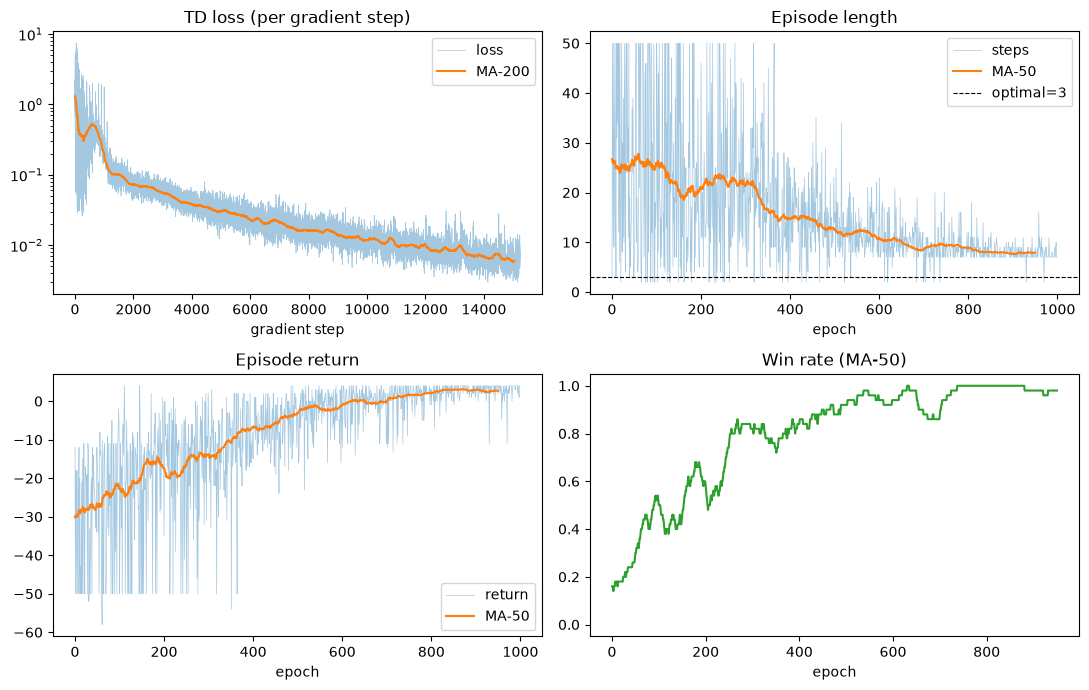

final 50-epoch win rate : 0.98
final 50-epoch mean len : 7.94  (optimal = 3)


In [12]:
# 训练曲线: loss / 每回合步数 / 每回合累计 reward / 滑动胜率
def moving_avg(x, w):
    x = np.asarray(x, dtype=float)
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w) / w, mode='valid')

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

axes[0, 0].plot(losses, lw=0.5, alpha=0.4, label='loss')
axes[0, 0].plot(moving_avg(losses, 200), color='C1', label='MA-200')
axes[0, 0].set_title('TD loss (per gradient step)')
axes[0, 0].set_xlabel('gradient step')
axes[0, 0].set_yscale('log')
axes[0, 0].legend()

axes[0, 1].plot(ep_lengths, lw=0.5, alpha=0.4, label='steps')
axes[0, 1].plot(moving_avg(ep_lengths, 50), color='C1', label='MA-50')
axes[0, 1].axhline(3, color='k', ls='--', lw=0.8, label='optimal=3')
axes[0, 1].set_title('Episode length')
axes[0, 1].set_xlabel('epoch')
axes[0, 1].legend()

axes[1, 0].plot(ep_returns, lw=0.5, alpha=0.4, label='return')
axes[1, 0].plot(moving_avg(ep_returns, 50), color='C1', label='MA-50')
axes[1, 0].set_title('Episode return')
axes[1, 0].set_xlabel('epoch')
axes[1, 0].legend()

axes[1, 1].plot(moving_avg(ep_wins, 50), color='C2')
axes[1, 1].set_title('Win rate (MA-50)')
axes[1, 1].set_xlabel('epoch')
axes[1, 1].set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

print(f'final 50-epoch win rate : {np.mean(ep_wins[-50:]):.2f}')
print(f'final 50-epoch mean len : {np.mean(ep_lengths[-50:]):.2f}  (optimal = 3)')

In [13]:
m = torch.tensor([2.0], requires_grad=True)
b = torch.tensor([1.0], requires_grad=True)

In [14]:
def linear_model(x:torch.tensor, m:torch.tensor, b:torch.tensor):
    y = m @ x + b
    return y

y = linear_model(torch.tensor([4.0]), m, b)


In [15]:
print(y)

tensor([9.], grad_fn=<AddBackward0>)


In [16]:
y.grad_fn

In [17]:
y.backward()
m.grad

tensor([4.])

In [18]:
b.grad

tensor([1.])

In [19]:
def test_model(model, mode='static', display=True):
    
    for _ in range(epochs):
        test_game = Gridworld(6, 'static') # Player

        while True:
            
            state_ = test_game.board.render_np.reshape(64) + np.random.rand(64) / 10
            state_cur = torch.from_numpy(state_)
            action_ = model(state_cur) # 4 tensor
            choice = epsilon_greedy(action_) # choice 0 1 2 3 
            action = action_set[choice]
            




            if terminal: break

        
